In [4]:
import torch
import torchlens as tl

from resnet import BasicBlock, ResNet18

ResNet18 | input (1, 3, 32, 32) float32
view: module tree, depth 2 of 4, 1 fold, 1 root-level ops in totals
name (type)                  output             params        (%)  fwd flops
----------------------------------------------------------------------------
conv1 (Conv2d)               (1, 64, 32, 32)     1.73K   ... 0.0%      3.54M
bn1 (BatchNorm2d)            (1, 64, 32, 32)       128   ... 0.0%    327.68K
relu (ReLU)                  (1, 64, 32, 32)         -          -     65.54K
layer1 (Sequential)          (1, 64, 32, 32)   147.97K   ... 1.3%    303.69M
  0..1 (BasicBlock x2)       (1, 64, 32, 32)   147.97K   ... 1.3%    303.69M
layer2 (Sequential)          (1, 128, 16, 16)  525.57K   ... 4.7%    269.45M
  0 (BasicBlock)             (1, 128, 16, 16)  230.14K   ... 2.1%    118.03M
  1 (BasicBlock)             (1, 128, 16, 16)  295.42K   ... 2.6%    151.42M
layer3 (Sequential)          (1, 256, 8, 8)       2.1M  #.. 18.8%    268.94M
  0 (BasicBlock)             (1, 256, 8, 8)  

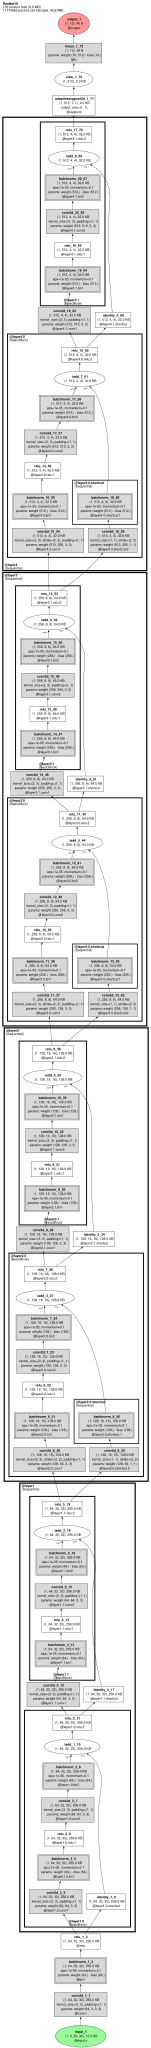

'// Computational graph for the feedforward sweep\ndigraph ResNet18 {\n\tgraph [bgcolor=white fontname=Helvetica label=<<FONT COLOR=\'black\'><B>ResNet18</B><br align=\'left\'/>155 tensors total (8.6 MB)<br align=\'left\'/>11173962 params (all trainable, 42.6 MB)<br align=\'left\'/></FONT>> labeljust=left labelloc=t ordering=out rankdir=BT]\n\tnode [fontname=Helvetica ordering=out]\n\tedge [fontname=Helvetica]\n\tinput_1pass1 [label=<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="2"><TR><TD ALIGN="CENTER"><B>input_1</B></TD></TR><TR><TD ALIGN="CENTER">(1, 3, 32, 32), 12.0 KB</TD></TR><TR><TD ALIGN="CENTER">@input.x</TD></TR></TABLE>> color=black fillcolor="#98FB98" fontcolor=black ordering=out shape=oval style="filled,solid"]\n\tinput_1pass1 -> conv2d_1_1pass1 [arrowsize=.7 color=black fontcolor=black labelfontsize=8 style=solid]\n\tconv2d_1_1pass1 [label=<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="2"><TR><TD ALIGN="CENTER"><B>conv2d_1_1</B></TD></TR><

In [8]:
# Instantiate the model
model = ResNet18()

# Set the model to evaluation mode
model.eval()

# Create a dummy input (batch size 1, 3 channels, 32x32 image as in CIFAR-10)
dummy_input = torch.randn(1, 3, 32, 32)

# Use torchlens to trace and get the compute graph
log = tl.trace(model, dummy_input)

print(log.summary())          # module table, op count, FLOPs
log.draw()